<a href="https://colab.research.google.com/github/Azyur-i/CS182-03/blob/main/FA4/CO1FA4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Loading Libraries (and Setting Up Utilities)
# We import the core libraries we need:
# - NumPy for numerical computations
# - Scikit-learn helpers for dataset generation and splitting
# - Metrics for evaluation (accuracy + classification report)
# - Plotting tools for visualization

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA


In [ ]:
# 2. Defining Naive Beyes Class
# This is a custom implementation of Gaussian Naive Beyes
# fit() is to learn the mean, variance, and prior probability for each class
# predict() is to predict class labels for new samples
# pdf() is the Gaussian probability density function for each feature

class NaiveBayes:
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        self._mean = np.zeros((n_classes, n_features), dtype=np.float64)
        self._var = np.zeros((n_classes, n_features), dtype=np.float64)
        self._priors = np.zeros(n_classes, dtype=np.float64)

        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self._mean[idx, :] = X_c.mean(axis=0)
            self._var[idx, :] = X_c.var(axis=0)
            self._priors[idx] = X_c.shape[0] / float(n_samples)

    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)

    def _predict(self, x):
        posteriors = []

        for idx, c in enumerate(self.classes):
            prior = np.log(self._priors[idx])
            posterior = np.sum(np.log(self._pdf(idx, x)))
            posteriors.append(prior + posterior)

        return self.classes[np.argmax(posteriors)]

    def _pdf(self, class_idx, x):
        mean = self._mean[class_idx]
        var = self._var[class_idx] + 1e-9  # prevent divide-by-zero

        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator


In [ ]:
# 3. Creating / Loading the Dataset
# Here we generate a synthetic binary classification dataset:
# 1000 samples, 10 numeric features, 2 classes (0 and 1)
# This is to keep the notebook sustained and easy to run

X, y = datasets.make_classification(
    n_samples=1000,
    n_features=10,
    n_classes=2,
    random_state=123
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:", {c: int((y == c).sum()) for c in np.unique(y)})

X shape: (1000, 10)
y shape: (1000,)
Class distribution: {np.int64(0): 502, np.int64(1): 498}


In [ ]:
# 4. Splitting the dataset
# spliting the dataset into 80% trainin gand 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Train samples: 800
Test samples: 200


In [ ]:
# 5. Training and Testing
# We create an instance of our Naive bayes class
# We train it using the training dataset

nb = NaiveBayes()
nb.fit(X_train, y_train)

# On the test set, we run predictions to compute accuracy.

y_pred = nb.predict(X_test)


Naive Bayes classification accuracy: 0.955 

Classification Report:

              precision    recall  f1-score   support

           0       0.92      1.00      0.96       100
           1       1.00      0.91      0.95       100

    accuracy                           0.95       200
   macro avg       0.96      0.96      0.95       200
weighted avg       0.96      0.95      0.95       200



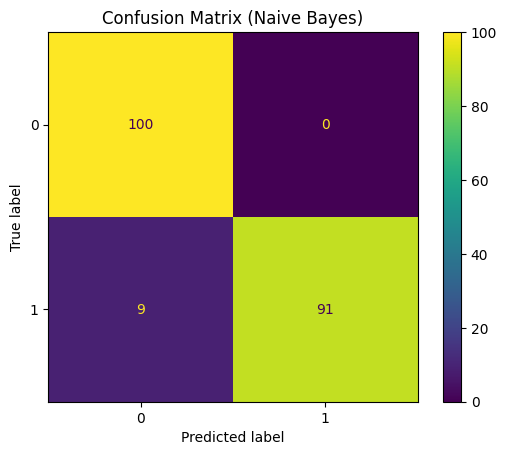

In [ ]:
# 7. Evaluation Report
# Classification report and Confusion matrix
# - classification_report shows precision, recall, f1-score per class
# - confusion_matrix shows counts of correct/incorrect predictions

acc = accuracy_score(y_test, y_pred)
print("Naive Bayes classification accuracy:", acc, "\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot()
plt.title("Confusion Matrix (Naive Bayes)")
plt.show()

**REFERENCES:**  

NumPy. https://numpy.org/doc/
Pandas - NumFOCUS, Inc. (2026). https://pandas.pydata.org/about/

NumPy Developers. (2024). NumPy [Computer software]. https://numpy.org/

The Matplotlib development team - Matplotlib (2012). https://matplotlib.org/

seaborn 0.13.2. https://seaborn.pydata.org/

Scikit-learn. https://scikit-learn.org/stable/about.html


